In [1]:
def f(x):
    return x**2+3*x +3

In [2]:
h = 0.001
x = 100
(f(x+h) - f(x))/h # 2*100 + 3

203.0010000016773

In [3]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h) # with respect to c 

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [4]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h) # with respect to b

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [53]:
import comp_graph_node
import importlib

importlib.reload(comp_graph_node)

from comp_graph_node import ComputationGraphNode

In [54]:
# a = ComputationGraphNode(1,label = 'a') 
# b = ComputationGraphNode(2,label = 'b')
# c = ComputationGraphNode(3,label = 'c')
# d = ComputationGraphNode(4,label = 'd')
# print(a)
# print(b)
# print(c)
# print(d)
# l = a + b*d + c*d*a
# print(l)

a = ComputationGraphNode(2, label='a')
b = ComputationGraphNode(3, label='b')
c = ComputationGraphNode(4, label='c')

y = a * b          # y = 6
z = y * c          # z = 24
l = y + z          # l = 30


print(l)

a * b + a * b * c - 30


In [55]:
#  l = a + b + c*d ==>  dl/da ==>  1 + 0 + 0 -> how to simulate this 
#  l = a + b*(c+d*c) + c*d ==>  dl/dc ==>  0 + b + b*d + d -> how to simulate this 
#  l = a + c*c*d ==>  dl/dc ==>  0 + 2*c*d -> how to simulate this 

# okay ig dont complicate just think of it as y = g(x)*f(x) => dy/dx = d(g(x)/dx)*f(x) + g(x)*(d(f(x)/dx)

In [56]:
# NOTE copy pasted from karpathy 

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

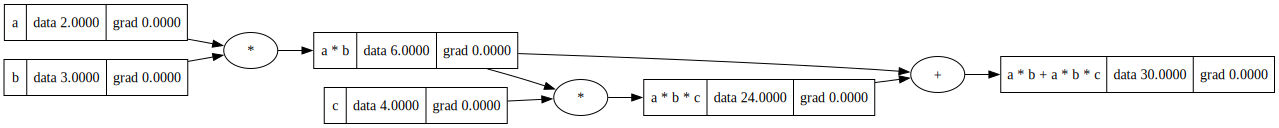

In [57]:
draw_dot(l)

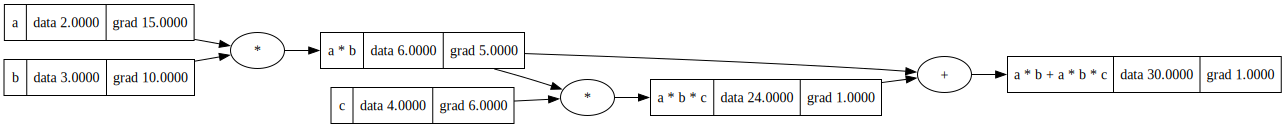

In [58]:
l.grad = 1.0
l.dfs_topo_backward()
draw_dot(l)

In [60]:
x1 = ComputationGraphNode(2, label='x1')
x2 = ComputationGraphNode(3, label='x2')
w1 = ComputationGraphNode(None,label='w1',requires_grad = True)
w2 = ComputationGraphNode(None,label='w2',requires_grad = True)
b = ComputationGraphNode(None,label='b',requires_grad = True)
y = w1*x1 + w2*x2 + b

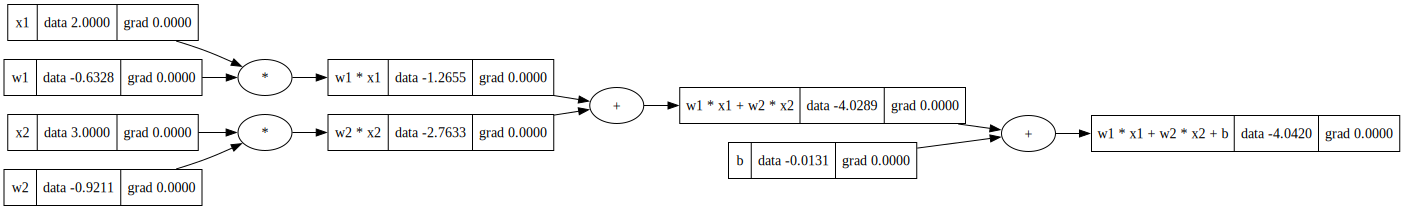

In [61]:
draw_dot(y)

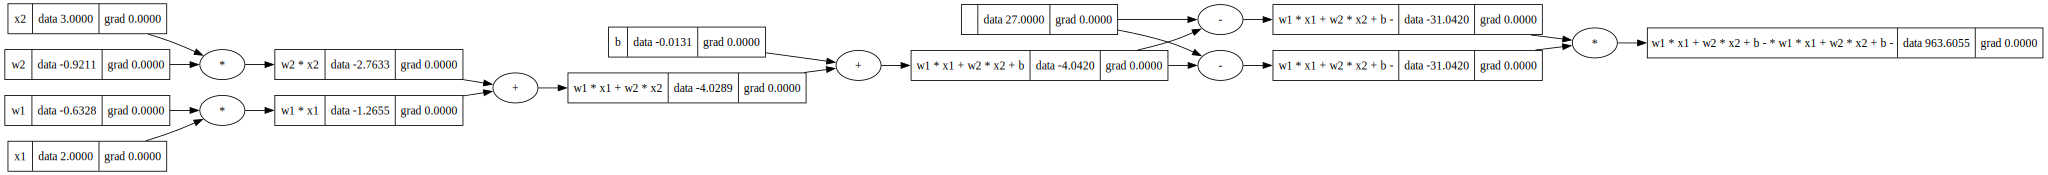

In [62]:
# let simulate 4x + 3y + 10
# for x = 2 , y = 3 ==> y truth = 27
y_true = ComputationGraphNode(27)
loss = (y - y_true) * (y - y_true) # MSE Loss 
draw_dot(loss)

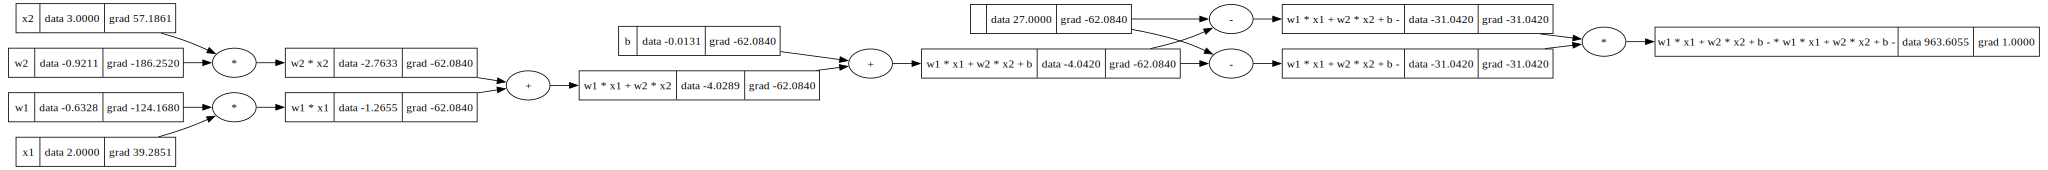

In [63]:
loss.dfs_topo_backward()
draw_dot(loss)

In [64]:
# Now next to simulate  w1 = w1 - n*dl/dw

In [ ]:
param = loss.parameters()

In [66]:
print(param)

[b - -0.013125601327732106, w2 - -0.921108008000797, w1 - -0.6327732628870297]


In [67]:
param[0].grad

-62.083992302208365

In [ ]:
from optimizers.SGD import SGD
# from optimizers.Optimizer import Optimizer

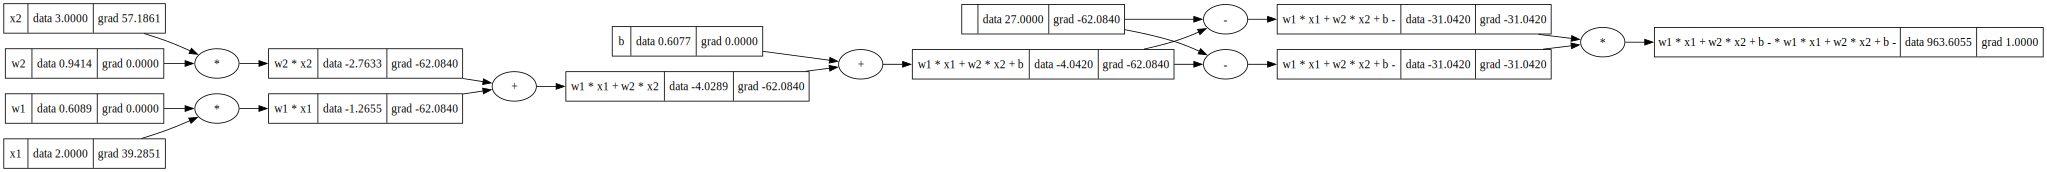

In [69]:

draw_dot(loss)

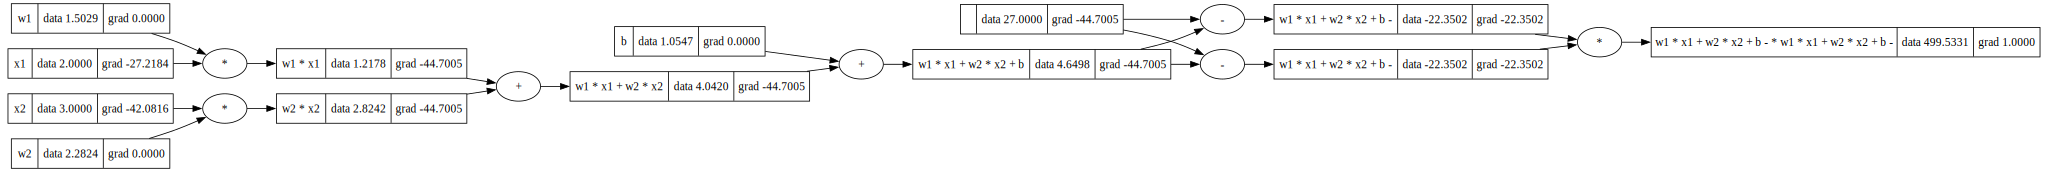

In [ ]:
#4x + 3y + 10
from optimizers.SGD import SGD
# from optimizers.Optimizer import Optimizer
param = loss.parameters()
opt = SGD(param)
x1 = ComputationGraphNode(2, label='x1')
x2 = ComputationGraphNode(3, label='x2')
y = w1*x1 + w2*x2 + b
y_true = ComputationGraphNode(27)
loss = (y - y_true) * (y - y_true)
loss.dfs_topo_backward()

opt.step()
opt.zero_grad()
draw_dot(loss)

In [76]:
#4x + 3y + 10
list = [(2,3), (4,5) , (2,2) , (1,4) , (4,1) , (5,2), (6,7) , (0,0) , (5,3) , (1,2)]
w1 = ComputationGraphNode(None,label='w1',requires_grad = True)
w2 = ComputationGraphNode(None,label='w2',requires_grad = True)
b = ComputationGraphNode(None,label='b',requires_grad = True)

opt = SGD([w1,w2,b])

for _ in range(100):
    total_loss = 0
    for x_val, y_val in list:
        opt.zero_grad()
        x1 = ComputationGraphNode(x_val, label='x1')
        x2 = ComputationGraphNode(y_val, label='x2')
        y = w1*x1 + w2*x2 + b
        y_true_val = (4*x_val + 3*y_val + 10)
        y_true = ComputationGraphNode(y_true_val)
        loss = (y - y_true) * (y - y_true)
        loss.dfs_topo_backward()
        opt.step()
        total_loss += loss.data
        # print(loss.data)
    print(total_loss)
    print()
    

2089.880946836185

364.3905030956852

281.39173477557466

231.5766317676013

197.79714735282494

172.5499462377162

152.34585843930955

135.4495556286724

120.928453864238

108.23775211939285

97.03138641035663

87.07163546593154

78.1836628372882

70.2314969377351

63.10472805704539

56.7108033575688

50.970362549226216

45.81428258438553

41.18171284352363

37.018701622458025

33.27718679070797

29.914218728001593

26.89133746949727

24.17405690371088

21.73142685871357

19.535654510686655

17.56177287224095

15.787347947995642

14.192218509956946

12.758263942668709

11.469196586892993

10.310375675546961

9.268640427531594

8.332160215570639

7.490299996016178

6.733499407605655

6.0531641281899935

5.441568233378357

4.891766435205575

4.397515196536486

3.9532018208849986

3.553780709757683

3.194716062115077

2.8719303643420506

2.5817580852508257

2.320904049967088

2.086406019814067

1.87560105314599

1.686095265065255

1.5157366425786836

1.362590606463624

1.2249180423125472

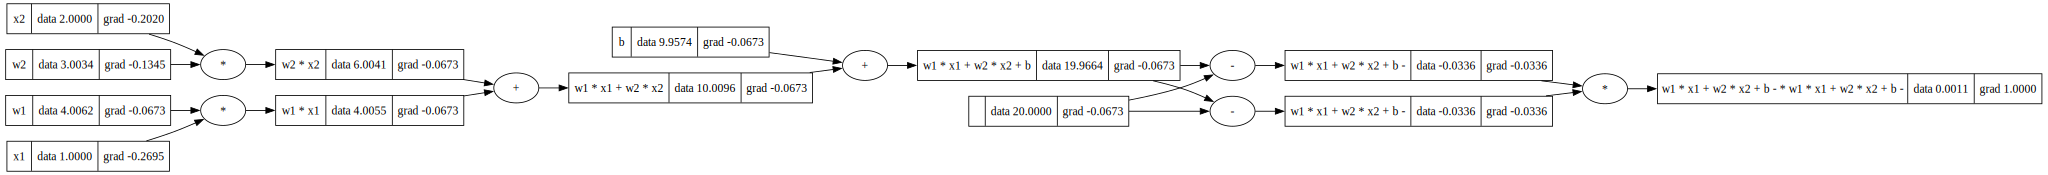

In [77]:
draw_dot(loss)